## Proyecto de aula
## Entrega 2: Ingenieria de caracteristicas

En este notebook se desarrollara la entrega 2 de la materia de analisis de datos de ingenieria de sistemas.

# Carga y comprension de datos




Lenin ospina 

Dariana lopera 

samuel osorio 

Ana Maria alucema 

`a`. Carguen el archivo de datos en pandas

In [290]:
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]


ROOT_DIR = Path().resolve().parent

DATA_DIR =  ROOT_DIR / "data/raw"

file_path = 'processed.cleveland.data'

df = pd.read_csv(
  
  url, names = columns
  
  )

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


`b`. Indique cúantas variables y registros tiene el dataframe, y asegúrense de que el tipo de dato de cada variable sea el esperado.


In [291]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


`conclusion`: Se puede apreciar que en el df hay 14 columnas, y 303 filas.

`conclusion`: Se puede apreciar como las variables 'ca' y 'thal' tienen como tipo str, lo que es incorreco ya que son datos float64.
Debido a esto, se revisa y encuentra que estas variables presentan varios registros nulos, por lo que se definen como nulos con el objetivo de que pandas escoja correctamente el tipado.

In [292]:
df = pd.read_csv(
  
  url, names = columns,
  na_values = ["?", "NA", "NaN", "nan", ""]
  
  )

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


<p style='color: red'>`c`. Reporte las estadisticas descriptivas de las variables numericas y categoricas </p>

<p style='color: white'> Antes de continuar, necesitamos convertir algunas variables que aparentan ser numericas, a si version categorica para su respectivo analisis. Estas puede verlas en la imagen en el archivo importations.ipynb </p>

In [293]:
# Conversion de variables
df['sex'] = df['sex'].astype(str)
df['cp'] = df['cp'].astype(str)
df['fbs'] = df['fbs'].astype(str)
df['restecg'] = df['restecg'].astype(str)
df['exang'] = df['exang'].astype(str)
df['slope'] = df['slope'].astype(str)
df['thal'] = df['thal'].astype(str)


<p style='color: red'>`Numericas` </p>

In [294]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2
ca,299.0,0.672241,0.937438,0.0,0.0,0.0,1.0,3.0
target,303.0,0.937294,1.228536,0.0,0.0,0.0,2.0,4.0


<p style='color: red'> `Categoricas` </p> 

In [295]:
df.describe(include='object').T

/tmp/ipykernel_8335/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
sex,303,2,1.0,206
cp,303,4,4.0,144
fbs,303,2,0.0,258
restecg,303,3,0.0,151
exang,303,2,0.0,204
slope,303,3,1.0,142
thal,301,3,3.0,166


`d`. Identifique si el dataframe tiene datos duplicados

In [296]:
df.duplicated().sum()

np.int64(0)

`conclusion`: Se puede apreciar como el dataframe no tiene valores duplicados.

`e`. Identifique si hay variables con valores nulos. 

In [297]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [298]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    str    
 2   cp        303 non-null    str    
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    str    
 6   restecg   303 non-null    str    
 7   thalach   303 non-null    float64
 8   exang     303 non-null    str    
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    str    
 11  ca        299 non-null    float64
 12  thal      301 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(6), int64(1), str(7)
memory usage: 33.3 KB


`conclusion`: Se puede apreciar como las variables 'ca' y 'thal' presentan valores nulos, lo que causo aque al inicio se les asignara erroneamente el tipo de dato. como solo hablamos de un total de 6 registros con datos nulos, correspondientes al 2% del dataset, eliminamos estos datos.

`f`. Reporten hallazgos en una celda de texto (Desarrollado a lo largo del taller) 

`g`. Descarten las variables que consideren irrelevantes para su modelo.

Necesitamos realizar el estudio de los datos para saber cuales pueden ser descartadas

In [299]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


`Conclusion`: Se descartaron las variables 'ca', 'thal y fbs, ya que las dos primeras presentan muchos datos nulos, por lo que se descarta, y se descarta fbs debido a que tiene poca varianza y mas del 85% es 0

`h`: Gestionen los datos duplicados y los datos nulos.

In [300]:
df = df.drop_duplicates()
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [301]:
df = df.dropna()

`Conclusion`: Ya que anteriormente se descartaron las unicas columnas con datos nulos, no se debe descartar ninguna columna en este paso. Ademas, se descartan los registros duplicados.

# 2. Analisis exploratorio de variables categóricas

`Conclusion`: Debido a que el dataframe no posee variables categoricas, el analisis exploratorio de variables categóricas no se puede realizar.

/tmp/ipykernel_8335/1392729003.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for cat in df.select_dtypes(include=['object']).columns:


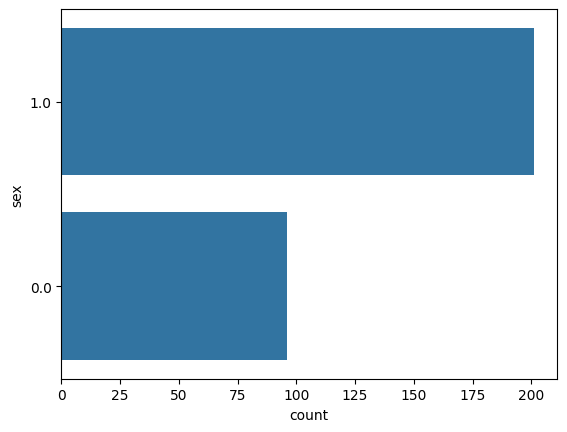

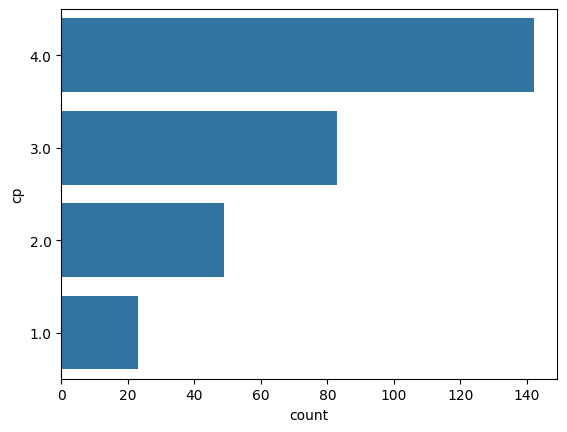

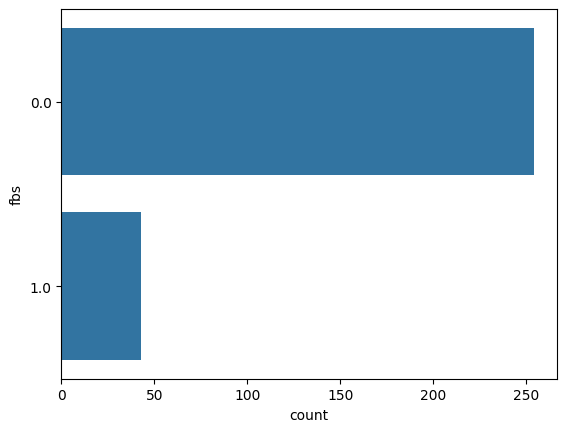

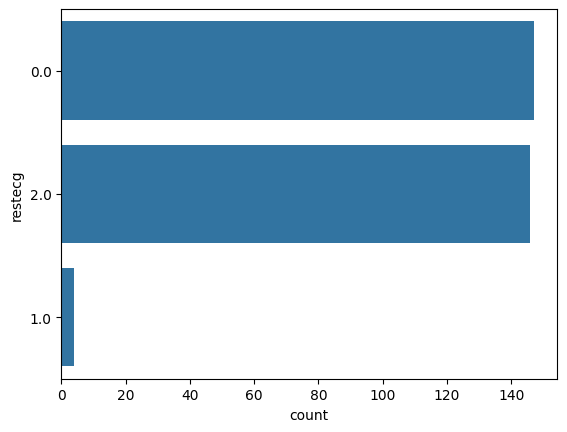

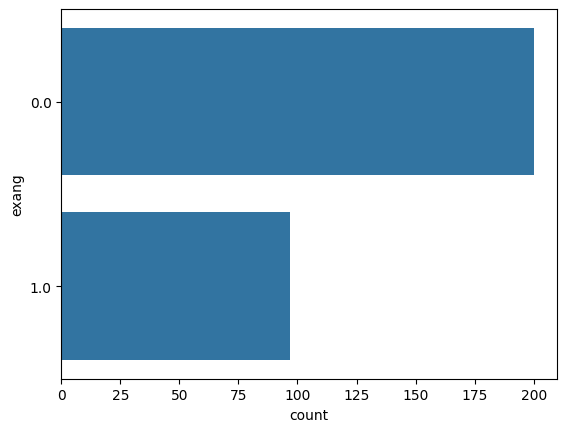

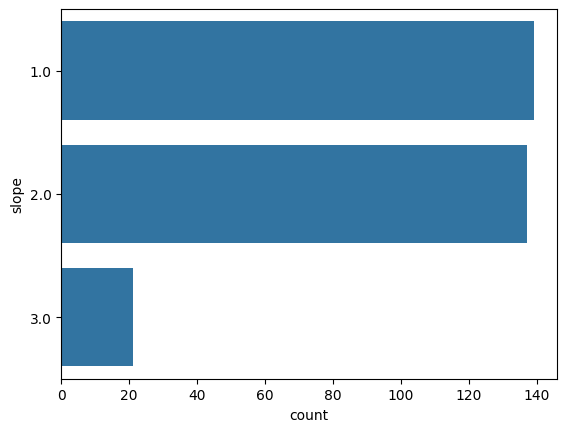

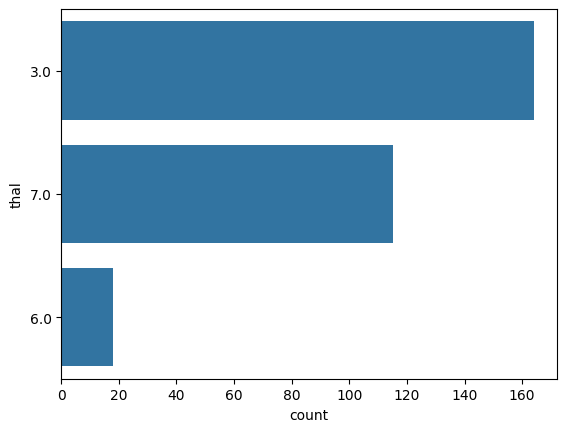

In [302]:
for cat in df.select_dtypes(include=['object']).columns:
    plt.figure()
    sns.countplot(data=df, y=cat, order=df[cat].value_counts().index)
    plt.show()

# Variables numéricas:

`a`. Identifiquen variables que sean (aproximadamente) normales y otras que tengan una distribución diferente.

Empezamos generando el historiograma, asintosis y kurtosis para verificar normalidad de las variables

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>],
       [<Axes: title={'center': 'thalach'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

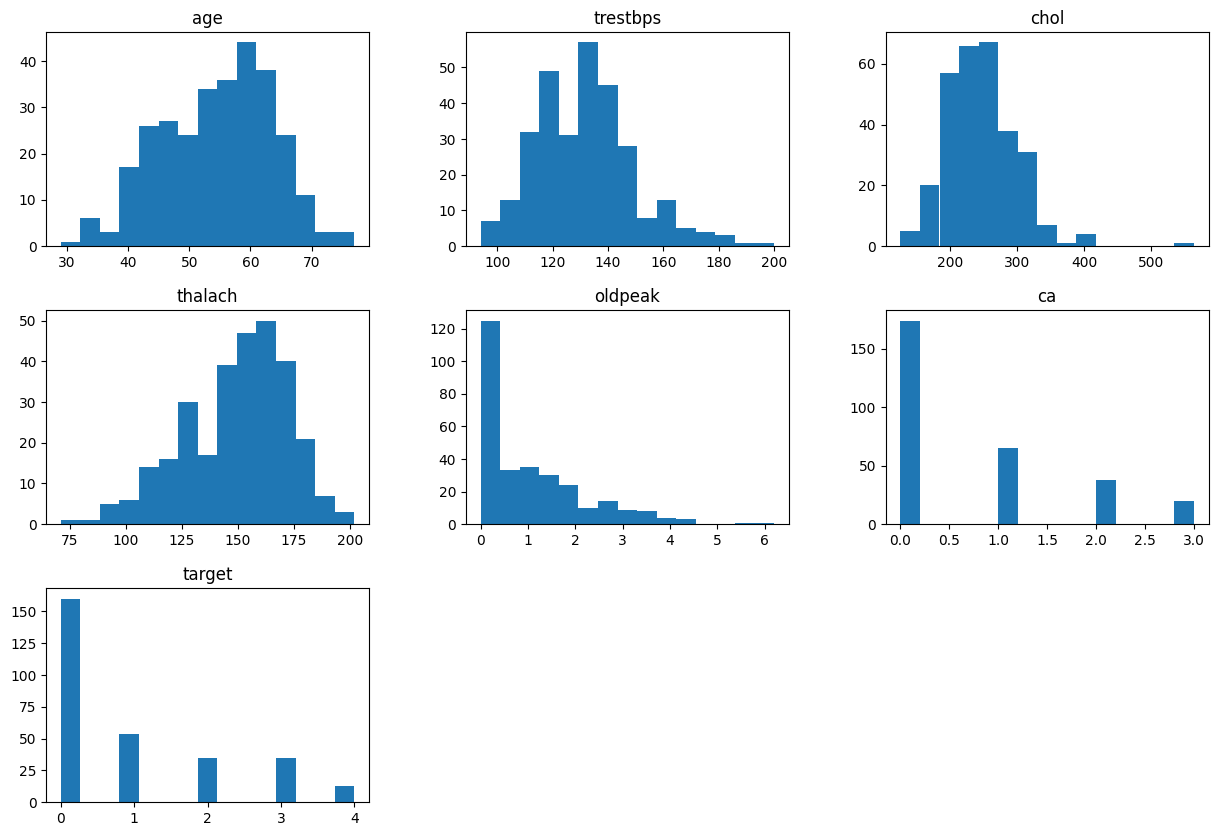

In [303]:
df.select_dtypes('number').hist(bins=15, figsize=(15, 10), grid=False,layout=(3, 3))

Obtencion de asimetria

In [304]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetria de {num}: {df[num].skew():.3f} \n")

Asimetria de age: -0.220 

Asimetria de trestbps: 0.700 

Asimetria de chol: 1.118 

Asimetria de thalach: -0.537 

Asimetria de oldpeak: 1.247 

Asimetria de ca: 1.180 

Asimetria de target: 1.047 



Obtencion de kurtosis

In [305]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"curtosisde {num}: {df[num].kurt():.3f} \n")

curtosisde age: -0.522 

curtosisde trestbps: 0.815 

curtosisde chol: 4.444 

curtosisde thalach: -0.052 

curtosisde oldpeak: 1.511 

curtosisde ca: 0.235 

curtosisde target: -0.174 



# Asimetria 

* age: distribucion casi simetrica con una cola muy leve a la izquierda 

* thalach: distribucion minimamente sesgada con una cola a la izquierda 

* Todas las demas variables tiene una asimetria muy alta


# Kurtosis 

* thalach y age : Tiende a una distribucion normal, sus colas son casi iguales 

* trestbps: Esta dentro de la zona normal, sin embargo, tiene una cola mas pesada a la derecha 

* Las otras varibles no tienden a ser normales 

Busqueda de Outlayers

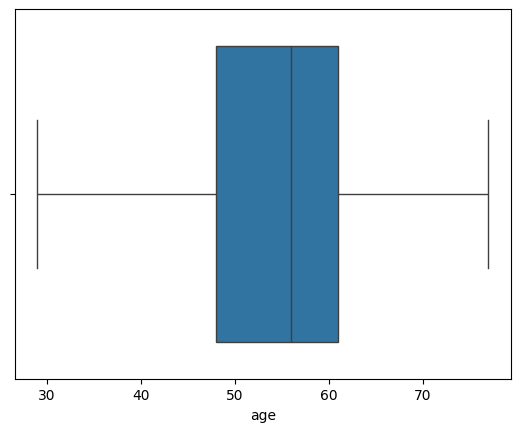

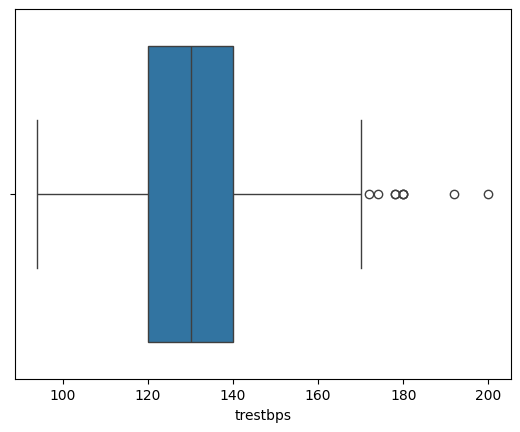

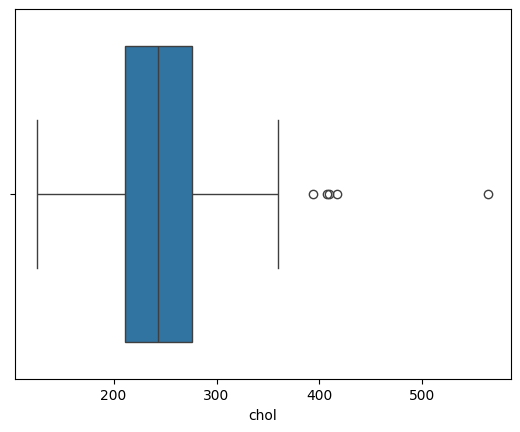

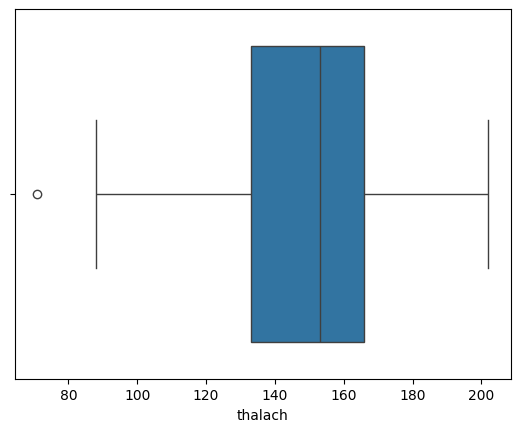

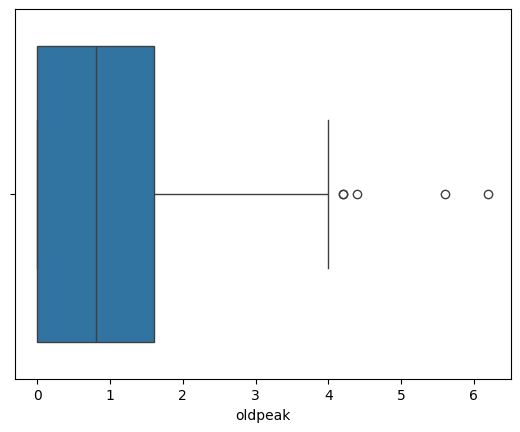

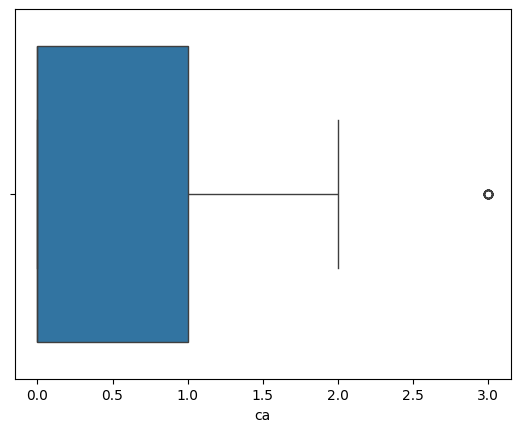

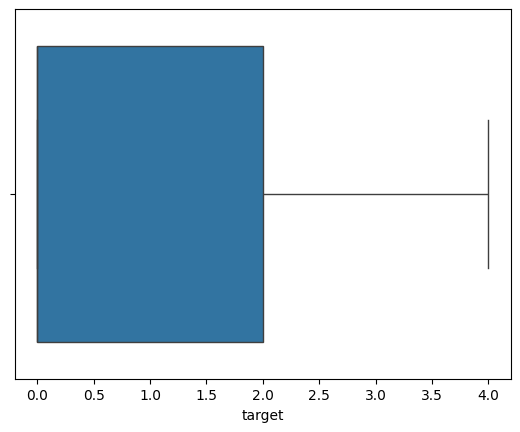

In [306]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show()

Las varibles a las que se le identificaron Outlayers: 

* trestbps

* chol

* oldpeak


Estrategias para eliminar outlayers segun la variable

* trestbps le aplicaremos zscore ya que tiende a distribuirse medianamente normal 

* oldpeak y chol se le aplicara rango intercusrtil por que cuando se intento con eliminacion de persentiles se eliminaron muchos datos

In [307]:
print("numero de registros:", df.shape[0])

numero de registros: 297


In [308]:
df["zscore"] = (df["trestbps"] - df["trestbps"].mean()) / df["trestbps"].std()
df= df[(df["zscore"]<3) & (df["zscore"]>-3)]
print("numero de registros:", df.shape[0])

numero de registros: 295


In [309]:
Q1 = df["oldpeak"].quantile(0.25)
Q3 = df["oldpeak"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["oldpeak"] < upper_bound) & (df["oldpeak"] > lower_bound)]
print("numero de registros:", df.shape[0])

numero de registros: 288


In [310]:
Q1 = df["chol"].quantile(0.25)
Q3 = df["chol"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["chol"] < upper_bound) & (df["chol"] > lower_bound)]
print("numero de registros:", df.shape[0])

numero de registros: 284


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>],
       [<Axes: title={'center': 'thalach'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'target'}>,
        <Axes: title={'center': 'zscore'}>, <Axes: >]], dtype=object)

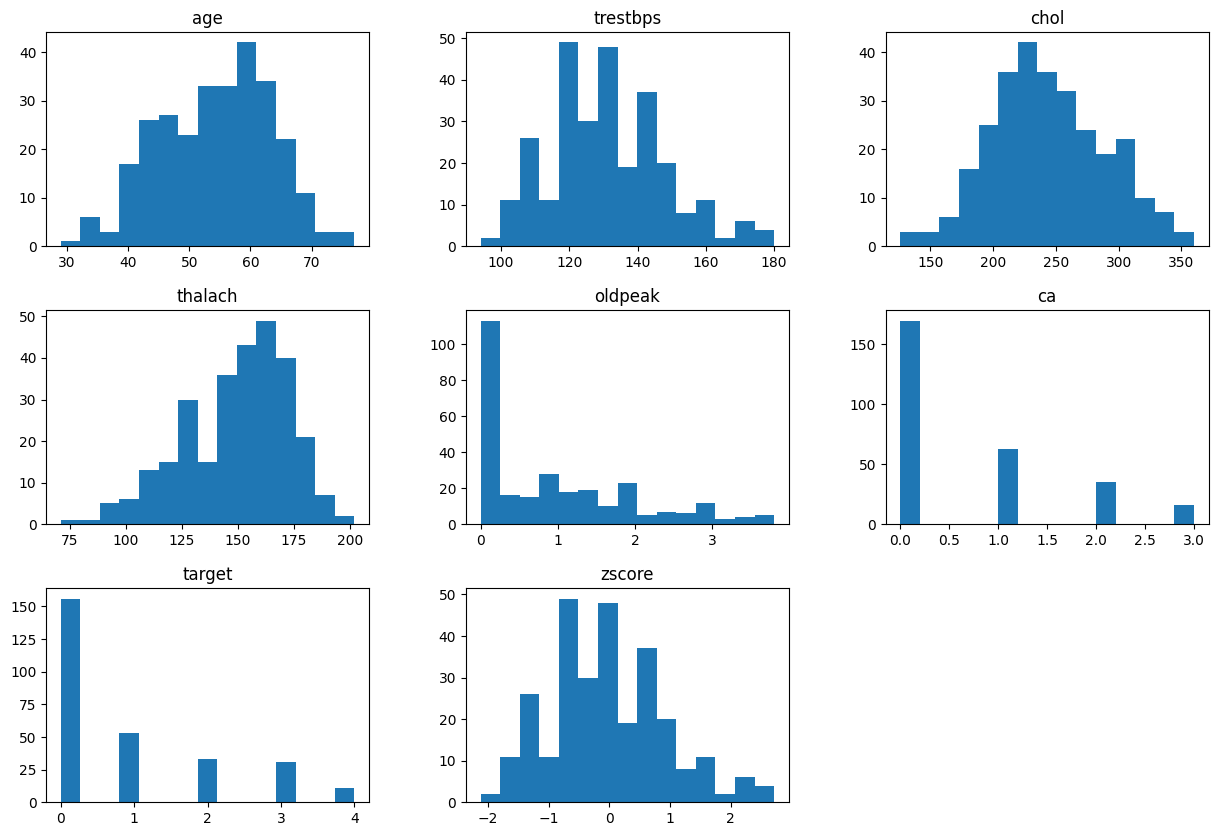

In [311]:
df.select_dtypes('number').hist(bins=15, figsize=(15, 10), grid=False,layout=(3, 3))

<Figure size 640x480 with 0 Axes>

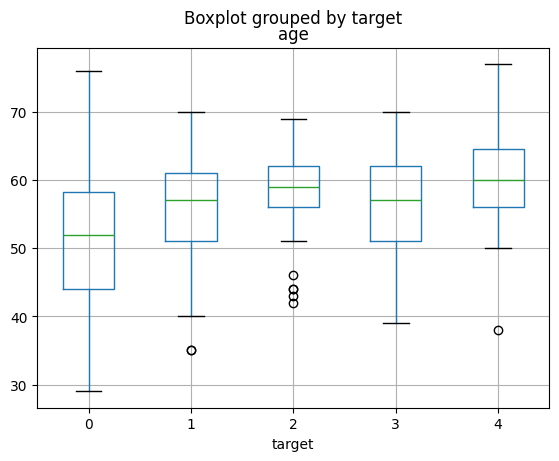

<Figure size 640x480 with 0 Axes>

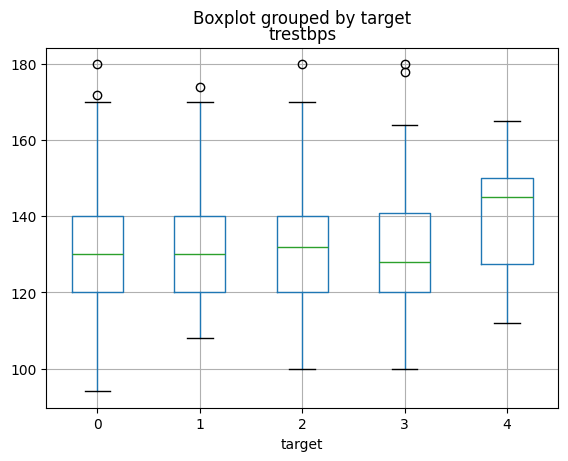

<Figure size 640x480 with 0 Axes>

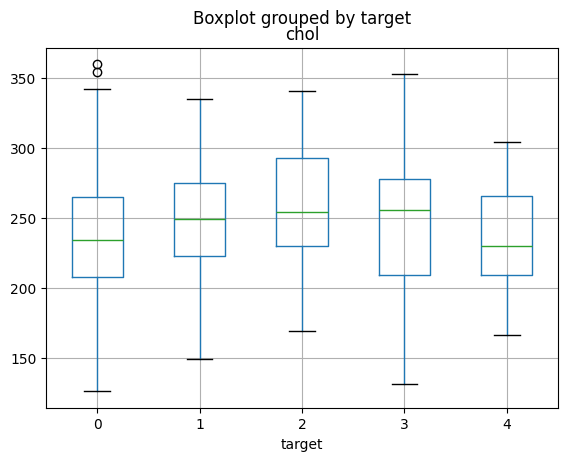

<Figure size 640x480 with 0 Axes>

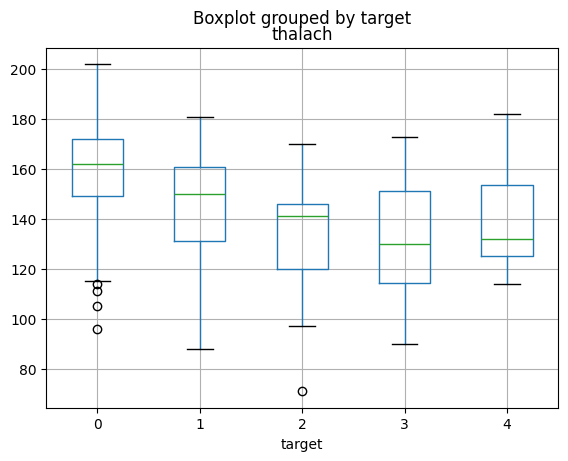

<Figure size 640x480 with 0 Axes>

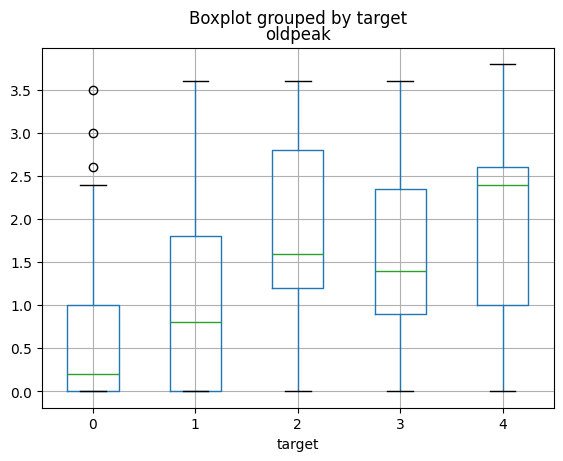

<Figure size 640x480 with 0 Axes>

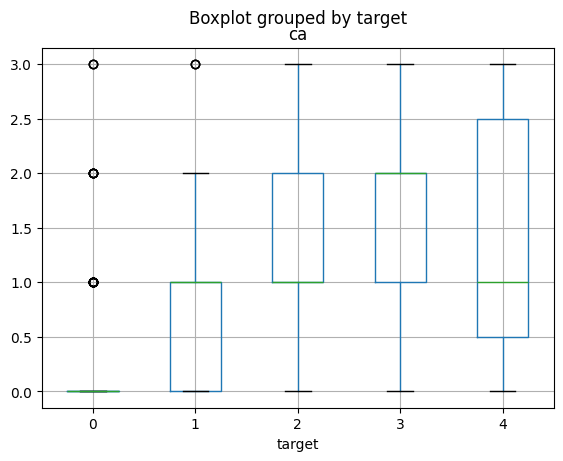

<Figure size 640x480 with 0 Axes>

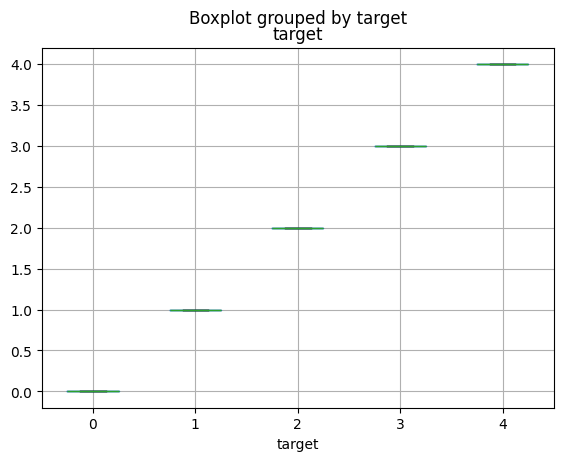

<Figure size 640x480 with 0 Axes>

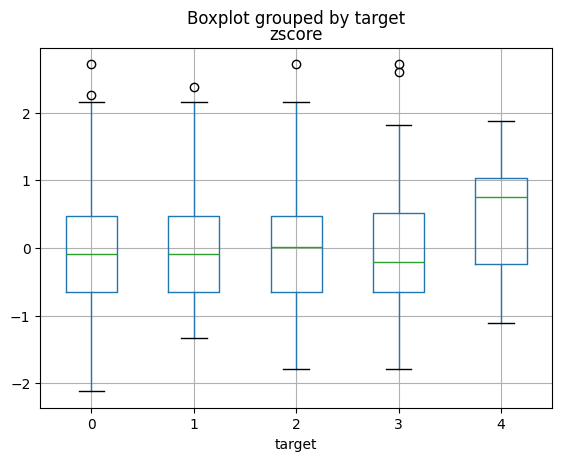

In [312]:
num_vars = df.select_dtypes(include=['number']).columns
for num in num_vars:
    plt.figure()
    df.boxplot(by="target", column=num)
    plt.title(num)
    plt.show()

# Analisis 

Se decide descartar la varible trestbps (la presión en reposo) los motivos son:

*  no ayuda mucho a predecir el target

* El modelo difícilmente encontrará patrones fuertes aquí debido a que los rangos son casi iguales en los valores que toma target

* las medianas son muy similares 

Decidimos manter chol(colesterol) ya que esta variablke si es un factor importante a la hora de predecir una enfermedad cardiaca 

In [313]:
df = df.drop(columns=["zscore", "trestbps"])


In [314]:
import numpy as np
from sklearn.discriminant_analysis import StandardScaler

scaler = StandardScaler()
df["oldpeak"] = np.log1p(df['oldpeak'])

# Matriz de correlacion 

<Axes: >

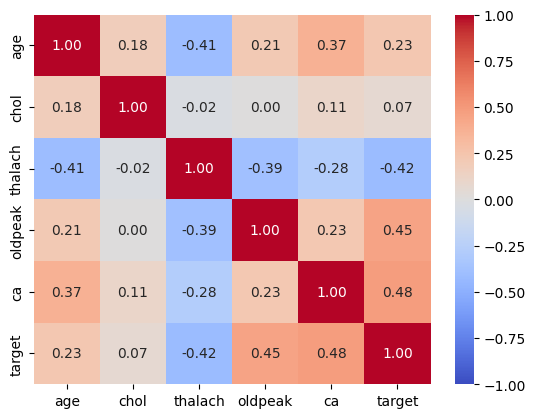

In [315]:
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

De esta matriz podemos concluir que: 

* Las variables ca, oldpeak, thalach influyen de manera significa a la variable predictoria target

* Las variables chol y age no ayudan a predir la variable predictoria target, por lo tanto podriamos eliminar chol 

In [316]:
df.drop(columns=["chol"], inplace=True)

In [317]:
df.info()

<class 'pandas.DataFrame'>
Index: 284 entries, 0 to 301
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      284 non-null    float64
 1   sex      284 non-null    str    
 2   cp       284 non-null    str    
 3   fbs      284 non-null    str    
 4   restecg  284 non-null    str    
 5   thalach  284 non-null    float64
 6   exang    284 non-null    str    
 7   oldpeak  284 non-null    float64
 8   slope    284 non-null    str    
 9   ca       284 non-null    float64
 10  thal     284 non-null    str    
 11  target   284 non-null    int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 28.8 KB


# Variables categoricas:  

In [318]:
var_categoricas = df.select_dtypes(include=['object']).columns
for var in var_categoricas:
    print(f"Variable: {var}: {df[var].unique()} \n")


Variable: sex: <StringArray>
['1.0', '0.0']
Length: 2, dtype: str 

Variable: cp: <StringArray>
['1.0', '4.0', '3.0', '2.0']
Length: 4, dtype: str 

Variable: fbs: <StringArray>
['1.0', '0.0']
Length: 2, dtype: str 

Variable: restecg: <StringArray>
['2.0', '0.0', '1.0']
Length: 3, dtype: str 

Variable: exang: <StringArray>
['0.0', '1.0']
Length: 2, dtype: str 

Variable: slope: <StringArray>
['3.0', '2.0', '1.0']
Length: 3, dtype: str 

Variable: thal: <StringArray>
['6.0', '3.0', '7.0']
Length: 3, dtype: str 



/tmp/ipykernel_8335/3845873462.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  var_categoricas = df.select_dtypes(include=['object']).columns


Se puede concluir que ninguna variable es de alta cardinalidad y tiene pocas categorias definidas 

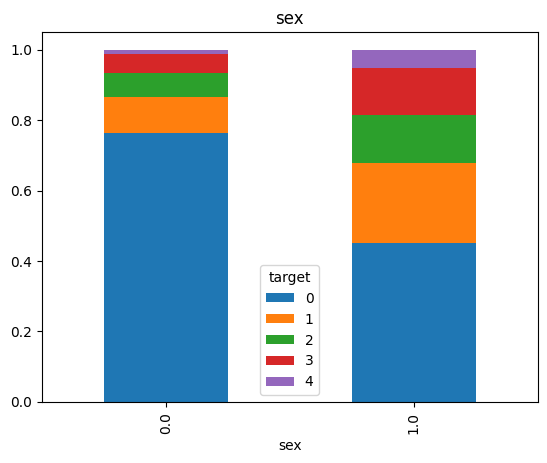

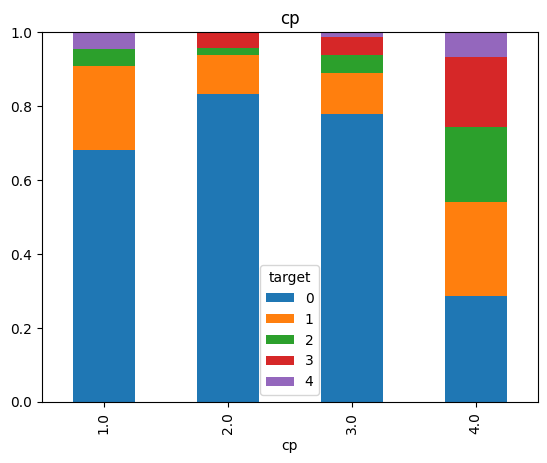

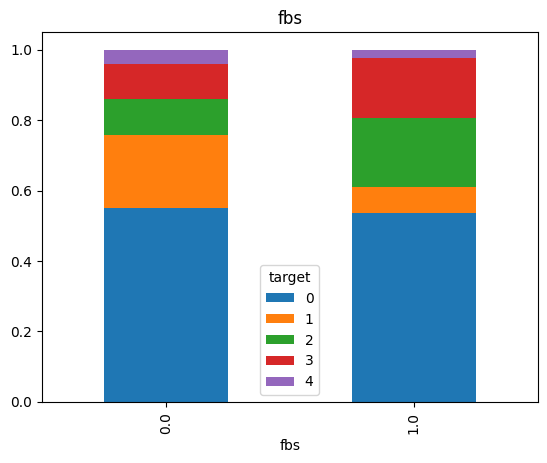

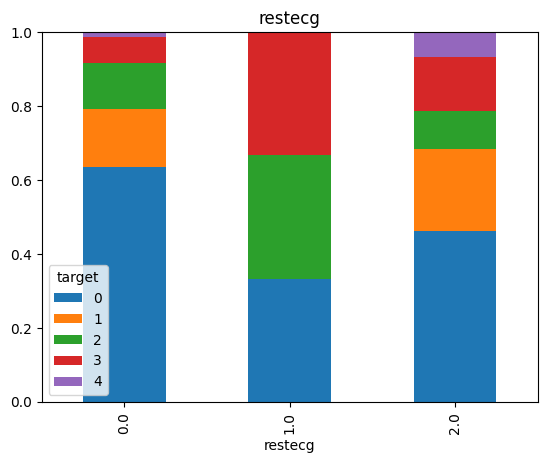

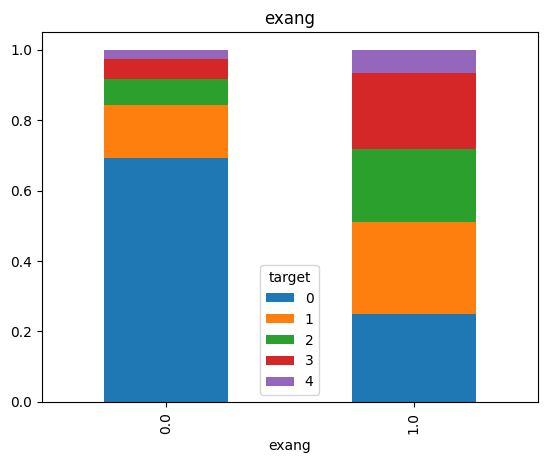

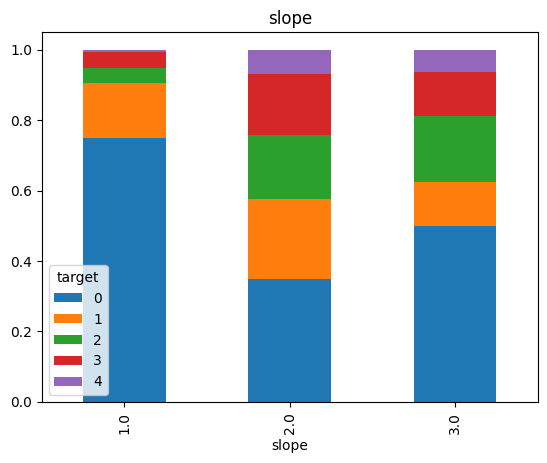

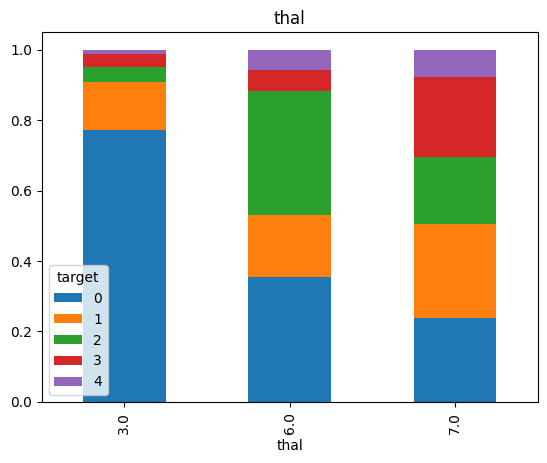

In [319]:
import matplotlib.pyplot as plt

#analsis bivairado entre variables categoricas y variable objetivo: churn label
for var in var_categoricas:
    tabla = pd.crosstab(df[var], df['target'], normalize='index')
    tabla.plot(kind='bar', stacked=True)
    plt.title(var)
    plt.show()

# Analisis 

Se decide eliminar la variable fbs(cantidad de glusemis en ayunas como indicador de diabetis) porque para predecir si una persona padece enfermedad cardiovascular (target) no influye segun la muestra la cantidad de glucosa.

In [320]:
df = df.drop(columns=["fbs"])

In [321]:
df.info()

<class 'pandas.DataFrame'>
Index: 284 entries, 0 to 301
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      284 non-null    float64
 1   sex      284 non-null    str    
 2   cp       284 non-null    str    
 3   restecg  284 non-null    str    
 4   thalach  284 non-null    float64
 5   exang    284 non-null    str    
 6   oldpeak  284 non-null    float64
 7   slope    284 non-null    str    
 8   ca       284 non-null    float64
 9   thal     284 non-null    str    
 10  target   284 non-null    int64  
dtypes: float64(4), int64(1), str(6)
memory usage: 26.6 KB


In [322]:
df.isnull().sum()

age        0
sex        0
cp         0
restecg    0
thalach    0
exang      0
oldpeak    0
slope      0
ca         0
thal       0
target     0
dtype: int64

# Preprocesamiento de los datos

In [323]:
from sklearn.model_selection import train_test_split

X = df.drop(['target'], axis=1)
df['target'] = (df['target']> 0).astype(int)
y = df['target']
#primero siempre se dividen los datos en entrenamiento y prueba, luego se hace el preprocesamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (198, 10)
Tamaño del conjunto de prueba es: (86, 10)


In [324]:
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
)

# Primero se definen los preprocesadores para cada tipo de variable para luego usarlos en las variables correspondientes

ss = StandardScaler() # Para preprocesar age y hours-per-week
pt = PowerTransformer() # Para preprocesar fnlwgt
orden1 = ['1.0', '2.0', '3.0'] # Para preprocesar slope
ore1 = OrdinalEncoder(categories=[orden1], dtype='float') # Para preprocesar slope
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') # workclass, marital-status, occupation, relationship, race y sex

In [325]:
from sklearn.compose import ColumnTransformer

#Aqui se define el preprocesador completo, indicando qué preprocesador se aplicará a cada variable. 
# Las demás columnas se descartan con remainder='drop'

preprocessor = ColumnTransformer(transformers=[
    ('num_prep', ss, ['age', 'thalach']), # Escalado
    ('num_prep2', pt, ['oldpeak','ca']), # Transformación
    ('cod_slope', ore1, ['slope']), # Codificación ordinal
    ('cod_oh', ohe, ['sex', 'cp', 'restecg', 'exang', 'thal'])
    ], remainder='drop') # Las demás columnas se descartan

In [326]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_prep', ...), ('num_prep2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

In [327]:
df.info()

<class 'pandas.DataFrame'>
Index: 284 entries, 0 to 301
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      284 non-null    float64
 1   sex      284 non-null    str    
 2   cp       284 non-null    str    
 3   restecg  284 non-null    str    
 4   thalach  284 non-null    float64
 5   exang    284 non-null    str    
 6   oldpeak  284 non-null    float64
 7   slope    284 non-null    str    
 8   ca       284 non-null    float64
 9   thal     284 non-null    str    
 10  target   284 non-null    int64  
dtypes: float64(4), int64(1), str(6)
memory usage: 26.6 KB


In [328]:
X_train.isnull().sum()

age        0
sex        0
cp         0
restecg    0
thalach    0
exang      0
oldpeak    0
slope      0
ca         0
thal       0
dtype: int64

# Entrenando el modelo

In [329]:
var_categoricas = X_train.select_dtypes(include="object").columns 
var_categoricas

/tmp/ipykernel_8335/702001772.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  var_categoricas = X_train.select_dtypes(include="object").columns


Index(['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], dtype='str')

In [330]:
#aqui ya estoy preparando los datos de entranamiento y a los de prueba 
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [333]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,     # importante para que converja
    random_state=1
)

model.fit(X_train_prep, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [334]:
print(f'Accuracy en el conjunto de entrenamiento: {model.score(X_train_prep, y_train)}')
print(f'Accuracy en el conjunto de prueba: {model.score(X_test_prep, y_test)}')

Accuracy en el conjunto de entrenamiento: 0.8737373737373737
Accuracy en el conjunto de prueba: 0.8255813953488372


se decidio convertir la variable y en una variable binario que nos permitiera saber si la persona padece o no la enfermedad independiente de lo avanzada que este, donde 0 es alivido y 1 es que tiene algun grado de la enfermedad de corazon por esto se decide utilizar un modelo de regresion logistica. 

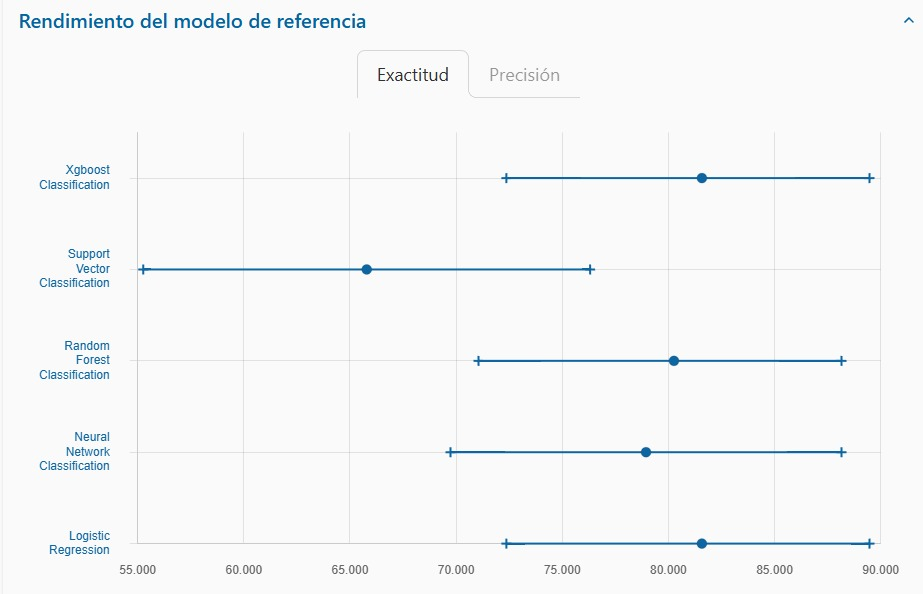